# HW03 —  KNN

## Используемый датасет
В данной работе оспользовался [набор данных](https://www.kaggle.com/datasets/mragpavank/breast-cancer) Breast cancer Wisconsin.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('data.csv')

# Проверка загрузки файла
display(df.head())
display(df.sample(5))
display(df.tail())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
503,915143,M,23.090,19.83,152.10,1682.0,0.09342,0.12750,0.167600,0.100300,...,23.87,211.50,2782.0,0.11990,0.36250,0.379400,0.22640,0.2908,0.07277,NaN
140,868999,B,9.738,11.97,61.24,288.5,0.09250,0.04102,0.000000,0.000000,...,14.10,66.53,342.9,0.12340,0.07204,0.000000,0.00000,0.3105,0.08151,NaN
367,9011495,B,12.210,18.02,78.31,458.4,0.09231,0.07175,0.043920,0.020270,...,24.04,93.85,624.6,0.13680,0.21700,0.241300,0.08829,0.3218,0.07470,NaN
297,892189,M,11.760,18.14,75.00,431.1,0.09968,0.05914,0.026850,0.035150,...,23.39,85.10,553.6,0.11370,0.07974,0.061200,0.07160,0.1978,0.06915,NaN
360,901034302,B,12.540,18.07,79.42,491.9,0.07436,0.02650,0.001194,0.005449,...,20.98,86.82,585.7,0.09293,0.04327,0.003581,0.01635,0.2233,0.05521,NaN


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [2]:
# размер датасета и типы признаков
print(df.shape)
df.info()

(569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             56

In [3]:
# статистика по числовым и строчным столбцам
display(df.describe())
display(df.describe(include='string'))

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


,diagnosis
count,569
unique,2
top,B
freq,357


In [4]:
# пропуски
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
# распределение классов
display(df['diagnosis'].value_counts(normalize=True))

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

### 2. Подготовка данных

Все данные впорядке, кроме 33 колонки - она вся нулевая, следовательно, ее можно просто удалить. Также можно удалить колонку `id`, потому что она не важна.

In [6]:
df = df.drop(columns=['Unnamed: 32', 'id'])
display(df.head())

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Выполним кодирование `diagnosis`, остальные данные численные:

In [7]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
display(df.sample(10))

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
392,1,15.490,19.97,102.40,744.7,0.11600,0.15620,0.18910,0.091130,0.1929,...,21.200,29.41,142.10,1359.0,0.1681,0.39130,0.5553,0.21210,0.3187,0.10190
175,0,8.671,14.45,54.42,227.2,0.09138,0.04276,0.00000,0.000000,0.1722,...,9.262,17.04,58.36,259.2,0.1162,0.07057,0.0000,0.00000,0.2592,0.07848
437,0,14.040,15.98,89.78,611.2,0.08458,0.05895,0.03534,0.029440,0.1714,...,15.660,21.58,101.20,750.0,0.1195,0.12520,0.1117,0.07453,0.2725,0.07234
46,0,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,8.964,21.96,57.26,242.2,0.1297,0.13570,0.0688,0.02564,0.3105,0.07409
312,0,12.760,13.37,82.29,504.1,0.08794,0.07948,0.04052,0.025480,0.1601,...,14.190,16.40,92.04,618.8,0.1194,0.22080,0.1769,0.08411,0.2564,0.08253
462,0,14.400,26.99,92.25,646.1,0.06995,0.05223,0.03476,0.017370,0.1707,...,15.400,31.98,100.40,734.6,0.1017,0.14600,0.1472,0.05563,0.2345,0.06464
236,1,23.210,26.97,153.50,1670.0,0.09509,0.16820,0.19500,0.123700,0.1909,...,31.010,34.51,206.00,2944.0,0.1481,0.41260,0.5820,0.25930,0.3103,0.08677
300,1,19.530,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.106200,0.1792,...,25.930,26.24,171.10,2053.0,0.1495,0.41160,0.6121,0.19800,0.2968,0.09929
79,0,12.860,18.00,83.19,506.3,0.09934,0.09546,0.03889,0.023150,0.1718,...,14.240,24.82,91.88,622.1,0.1289,0.21410,0.1731,0.07926,0.2779,0.07918
131,1,15.460,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.080870,0.1931,...,19.260,26.00,124.90,1156.0,0.1546,0.23940,0.3791,0.15140,0.2837,0.08019


Подготовим `train` и `test`:

In [8]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape} ")
print(f"Test shape: {y_test.shape} ")


Train shape: (455, 30) 
Test shape: (114,) 


Масштабируем признаки:

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

#### Почему масштабирование важно для KNN?
Отсутсвие масштабирования будет плохо сказываться на корректность метрики. Например, при очень больших значениях некоторых прихнаков алгоритм будет смещен в сторону больших значений, фактически игнорируя признаки со сравнительно малыми значениями. Из за этого моет просесть точность модели

#### Почему нельзя подбирать параметры на тестовой выборке?
Потому что, если мы обучим модель на тестовом наборе, то мы максимум сможем получить хорошую точность только для этого набора данных. Модель начинает подстраиваться под конкретные особенности и шумы именно этого набора данных, в итоге на тесте мы получим отличный результат, но на новых реальных данных точность резко упадет.

### Обучение KNN

In [15]:
# Обучение KNN
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights = 'uniform')
knn.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
y_pred = knn.predict(X_test_scaled)
print(f"Точность: {accuracy_score(y_test, y_pred):.3f}")

Точность: 0.956


#### Влияние параметров

Составим графики точности модели в зависимости от `k` и метрик, а также найдем лучшие параметры.

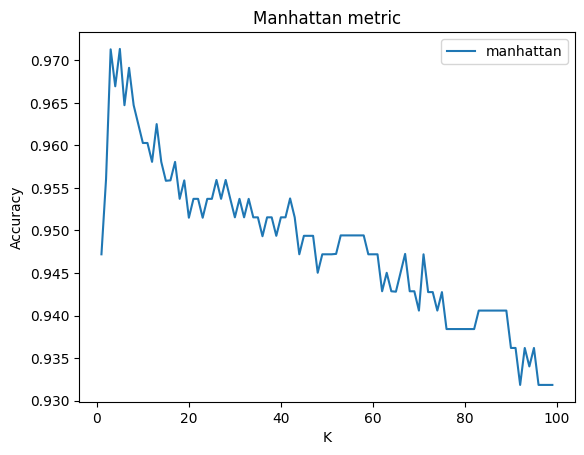

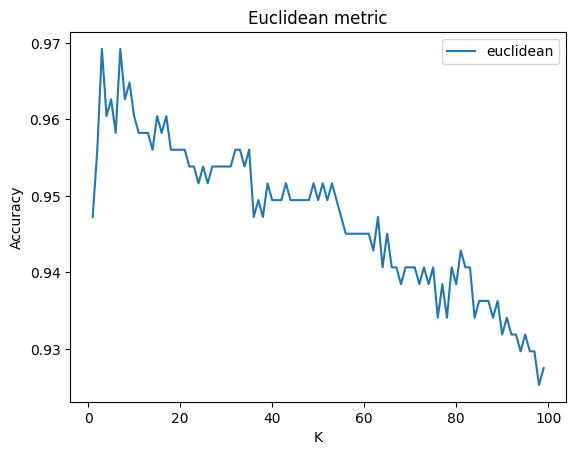

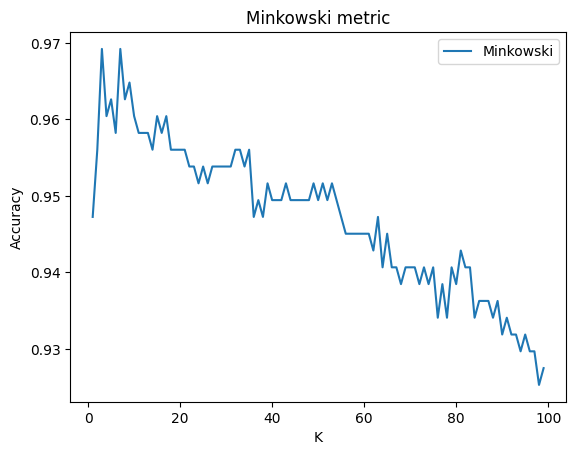

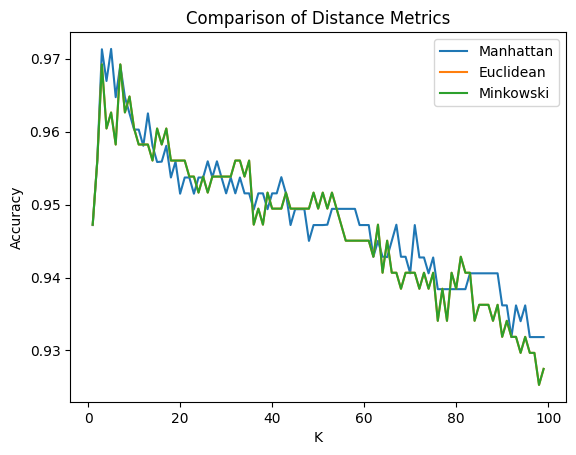

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Лучшая метрика: 0.9713526570048309


In [14]:
k_range = range(1, 100)
scores_manhattan = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=10)
    scores_manhattan.append(cv_scores.mean())

plt.plot(k_range, scores_manhattan, label='manhattan')
plt.xlabel('K'); plt.ylabel('Accuracy'); plt.title('Manhattan metric')
plt.legend()
plt.show()

scores_euclidean = []
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    scores_euclidean.append(cv_scores.mean())

plt.plot(k_range, scores_euclidean, label='euclidean')
plt.xlabel('K'); plt.ylabel('Accuracy'); plt.title('Euclidean metric')
plt.legend()
plt.show()

scores_minkowski = []
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski')
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    scores_minkowski.append(cv_scores.mean())

plt.plot(k_range, scores_minkowski, label='Minkowski')
plt.xlabel('K'); plt.ylabel('Accuracy'); plt.title('Minkowski metric')
plt.legend()
plt.show()

plt.plot(k_range, scores_manhattan, label='Manhattan')
plt.plot(k_range, scores_euclidean, label='Euclidean')
plt.plot(k_range, scores_minkowski, label='Minkowski')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Comparison of Distance Metrics')
plt.legend()
plt.show()

param_grid = {
    'n_neighbors': range(1, 100, 2),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая метрика: {grid.best_score_}")

В ходе экспериментов было установлено, что точность модели растёт с увеличением `k` до определённого порога, после чего стабилизируется или начинает снижаться.

- **Пиковая точность (0.956)** достигается при `k` ≈ 3–5
- **Стабильная зона** (`k` ≈ 5–40): точность держится на уровне **0.947**
- **Спад качества** (`k` ≈ 70–100): точность падает до **0.930–0.904** из-за чрезмерного обобщения

**Вывод:** Метрика **Manhattan** показала наилучший результат среди всех рассмотренных.

#### Анализ зависимости от `k`

| Диапазон `k` | Поведение | Точность | Причина |
|-------------|-----------|----------|---------|
| 1–2 | Переобучение | 0.930–0.912 | Модель слишком следует шумам в данных |
| **3–5** | **Оптимальный** | **0.939–0.956** | Лучший баланс между смещением и дисперсией |
| 10–50 | Стабильный | ~0.947 | Модель работает стабильно, но теряет чувствительность |
| 70–100 | Спад качества | 0.930–0.904 | Чрезмерное обобщение, потеря важных паттернов |

#### Результаты GridSearchCV

Для подбора оптимальных гиперпараметров использовался **GridSearchCV** с 10-кратной кросс-валидацией.

```python
Лучшие параметры: {
    'metric': 'manhattan',
    'n_neighbors': 5,
    'weights': 'uniform'
}